# Introduction

Here we employ what we have implemented in Assignment 3 and 6, namely the following methods:
- PCA
- MDS
- LLE
- IsoMap

Note that this notebook requires normalized version of the data set, which is provided via another Jupyter notebook (see project readme).
The cells below are a mix of our previous assignments' source codes.

In [158]:
!pip install scikit-learn==1.8.0
!pip install -U kaleido
# 1.8 is needed for the recent function call arguments in MDS

In [159]:
import pandas as pd
import numpy as np
import time
import math
import datetime
import seaborn as sns
import matplotlib.pylab as plt
import sklearn
import os
import scipy as sp

from sklearn.preprocessing import StandardScaler

In [160]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


In [161]:

if IN_COLAB:
    drive.mount('/content/drive')
else:
    print("Not running in Colab, skipping Drive mount.")

Not running in Colab, skipping Drive mount.


In [162]:

available_samplings = ["random", "proportional", "grid"]

##########################################
# Adjustable Globals
##########################################

LABEL_KEY = "Borough" # Options: PULocationID, DOLocationID, Borough (This one is for ground truth comparison, we stick with Borough in the end)


PROJECT_PATH = '.'
if IN_COLAB:
    PROJECT_PATH = '/content/drive/MyDrive/CENG574_PROJECT'
    
DATA_PATH = os.path.join(PROJECT_PATH, 'data')
PROJECT_RESULT_PATH = os.path.join(PROJECT_PATH, 'result')

SAMPLING_CHOICE = available_samplings[1] # <-------------- Change this one to determine sampling strategy




In [163]:

##########################################
# Setting up data set paths
##########################################

PROJECT_RESULT_PATH = os.path.join(PROJECT_RESULT_PATH, SAMPLING_CHOICE)

print("SAMPLING CHOICE:", SAMPLING_CHOICE)
if SAMPLING_CHOICE == available_samplings[0]:
  RANDOM_SAMPLING = True
  print("Using random sampling...")
  NORMALIZED_DATA_PATH = os.path.join(DATA_PATH, 'normalized_cleaned_partitions') # Full dataset is loaded

elif SAMPLING_CHOICE == available_samplings[1]:
  RANDOM_SAMPLING = False
  print("Using proportional sampling...")
  NORMALIZED_DATA_PATH = os.path.join(DATA_PATH, 'normalized_proportional_sampled_2k.parquet')
else:
  RANDOM_SAMPLING = False
  print("Using grid sampling...")
  NORMALIZED_DATA_PATH = os.path.join(DATA_PATH, 'normalized_nyc_taxi_grid_sampled.parquet')


SAMPLING CHOICE: proportional
Using proportional sampling...


In [164]:

df =  pd.read_parquet(NORMALIZED_DATA_PATH)

n_samples, n_features = df.shape
print(f"[INFO] Loaded data set with total samples: {n_samples}")
print(f"[INFO] Number of features (including Ground Truth): {n_features}")

[INFO] Loaded data set with total samples: 4158
[INFO] Number of features (including Ground Truth): 16


In [165]:
# Separate the ground truth from analysis
LABEL_COLUMNS = [
    "PULocationID",
    "DOLocationID",
    "Borough"
]

labels_df = df[LABEL_COLUMNS].copy()

features_df = df.drop(columns=LABEL_COLUMNS)
n_samples, n_features = features_df.shape
print(f"Dataset shape: {features_df.shape}")

Dataset shape: (4158, 13)


In [166]:
if RANDOM_SAMPLING:
  n_samples = len(features_df)
  n_subsamples = 2000

  random_idxs = np.random.choice(
      n_samples,
      size=n_subsamples,
      replace=False
  )

  X = features_df = features_df.iloc[random_idxs]
  labels_df = labels_df.iloc[random_idxs]

else:
  X  = features_df # Using the initial one

print("Working with dataset of shape: ", X.shape, " labels shape: ", labels_df.shape)


Working with dataset of shape:  (4158, 13)  labels shape:  (4158, 3)


## Visualization tools

In [167]:
import numpy as np
import matplotlib.pyplot as plt

# Combining both of our shepard diagram functions
def plot_shepard_diagram_with_line(
    original_distances,
    projected_distances,
    title="Shepard Diagram",
    save=True
):
    # Flatten distances
    original_flat = original_distances.flatten()
    projected_flat = projected_distances.flatten()

    # Debug info
    print(
        f"[DEBUG] Original distances: "
        f"min={original_flat.min():.4f}, "
        f"max={original_flat.max():.4f}, "
        f"std={original_flat.std():.4f}"
    )

    print(
        f"[DEBUG] Projected distances: "
        f"min={projected_flat.min():.4f}, "
        f"max={projected_flat.max():.4f}, "
        f"std={projected_flat.std():.4f}"
    )

    # Plot
    plt.figure(figsize=(8, 6))

    plt.scatter(
        original_flat,
        projected_flat,
        alpha=0.1,
        s=1,
        c="gray"
    )

    plt.axline(
        (0, 0),
        slope=1,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Preservation"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel(
        "Original Distances",
        fontsize=12
    )
    plt.ylabel(
        "Projected Distances",
        fontsize=12
    )

    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    if save:
        plt.savefig(os.path.join(PROJECT_RESULT_PATH, f'{title}.png'), dpi=300, bbox_inches='tight')

    plt.show()

In [168]:
def plot_long_lat_based(df, colors, labels=None, save_path=None, title=None):
  # PLOT
  fig, ax = plt.subplots(
      figsize=(12, 10)
  )

  scatter = ax.scatter(
      df["pickup_longitude"],
      df["pickup_latitude"],
      c=colors,
      s=25,
      alpha=0.6,
      cmap="rainbow"
  )

  handles, _ = scatter.legend_elements()
  if labels is not None:
    ax.legend(handles, labels, title=LABEL_KEY, bbox_to_anchor=(1.05, 1), loc='upper left')


  #ax.set_xlim((-74.15, -73.7004))
  #ax.set_ylim((40.5774, 40.9176))

  ax.set_xlabel("Longitude")
  ax.set_ylabel("Latitude")
  ax.grid(True, alpha=0.3)

  if title is None:
    ax.set_title(
        f"Pickup Taxi Zones ({LABEL_KEY})\n"
        f"{len(df):,} sampled trips, {len(labels)} zones"
    )
  else:
    ax.set_title(title)

  plt.tight_layout()
  if save_path is not None:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
  print(f"Figure saved to: {save_path}")


  plt.show()



In [169]:

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

def plot_mds_stress_vs_iterations(iterations, stress_values):

    plt.figure()

    plt.plot(iterations, stress_values, marker='o')

    plt.xlabel("Maximum Iterations")
    plt.ylabel("Stress (Error)")
    plt.title("MDS Stress vs. Iterations")

    plt.xticks(iterations)
    plt.grid(True)

    plt.savefig(os.path.join(PROJECT_RESULT_PATH, f'mds_stress_vs_iters.png'), dpi=300, bbox_inches='tight')

    plt.show()

In [170]:
import os
import numpy as np
import matplotlib.pyplot as plt

def visualize_2d_projection(
    projected_data,
    labels=None,
    title="2D Projection",
    save=True
):
    plt.figure(figsize=(9, 7))

    if labels is not None:

        labels = np.asarray(labels)

        for label in np.unique(labels):
            mask = labels == label

            plt.scatter(
                projected_data[mask, 0],
                projected_data[mask, 1],
                label=str(label),
                alpha=0.7,
                s=30
            )

        plt.legend()

    else:

        plt.scatter(
            projected_data[:, 0],
            projected_data[:, 1],
            alpha=0.7,
            s=30
        )

    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)

    if save:
        plt.savefig(
            os.path.join(PROJECT_RESULT_PATH, f"{title}.png"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

In [171]:
# Visualising the clusters on a map
# DISCLAIMER: Adapted from
# https://www.kaggle.com/code/elemento/nyc-yellowtriptaxi/notebook
def plot_long_lat(frame, max_samples=100000, save=True):
    city_long_border = (-74.03, -73.75)
    city_lat_border = (40.63, 40.85)
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize = (12, 10))

    long_vals = frame.pickup_longitude.values[:max_samples]
    lat_vals = frame.pickup_latitude.values[:max_samples]
    print(f"[DEBUG] Long_vals shape: {long_vals.shape}, lat_vals shape: {lat_vals.shape}")
    ax.scatter(long_vals, lat_vals,
              s=10, lw=0, alpha=0.8)
    #ax.set_xlim(city_long_border)
    #ax.set_ylim(city_lat_border)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'latlong_map.png'), dpi=300, bbox_inches='tight')

    plt.show()


In [172]:
os.makedirs(PROJECT_RESULT_PATH, exist_ok=True)

[DEBUG] Long_vals shape: (4158,), lat_vals shape: (4158,)


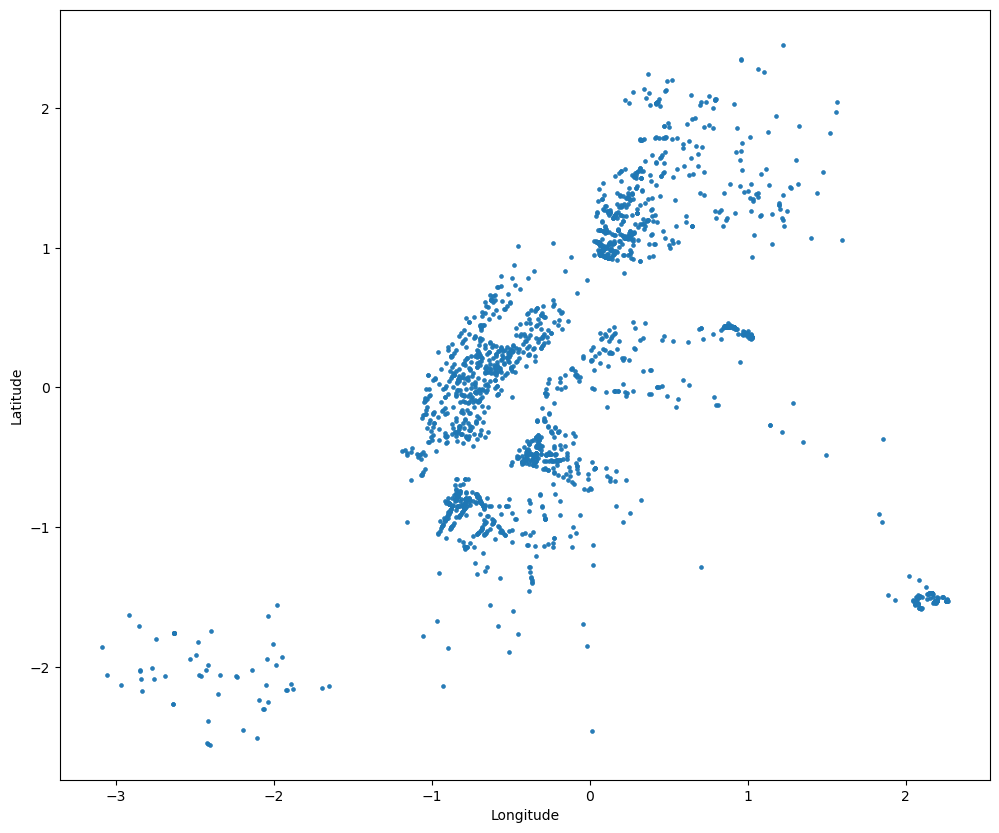

In [173]:
# Sanity check
plot_long_lat(frame=X)

# Principal Component Analysis (PCA)

In [174]:

# Use normalized data before PCA
X_normalized = features_df

pca = sklearn.decomposition.PCA()
tfdf= pca.fit_transform(X_normalized) # transformed data

eig_vals = evalf = pca.explained_variance_ # eigenvalues
eig_vecs = evecf = pca.components_ # eigenvectors
explained_var = vrf = pca.explained_variance_ratio_ # variance_ratio

print("Eigenvalues")
print(np.round(eig_vals, 4))

print("\nExplained Variance Ratio")
print(np.round(explained_var, 4))

Eigenvalues
[3.5895 2.3371 1.2123 1.0891 1.0148 0.9655 0.8791 0.6639 0.5421 0.3859
 0.2366 0.0769 0.0103]

Explained Variance Ratio
[0.2761 0.1797 0.0932 0.0838 0.078  0.0743 0.0676 0.0511 0.0417 0.0297
 0.0182 0.0059 0.0008]


## Scree Plot

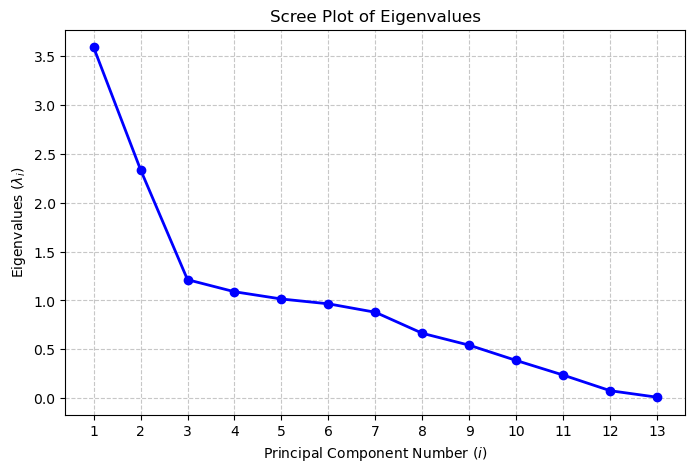

In [175]:
import matplotlib.pyplot as plt

components = np.arange(1, n_features + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, eig_vals, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Scree Plot of Eigenvalues')
plt.xlabel('Principal Component Number ($i$)')
plt.ylabel('Eigenvalues ($\\lambda_i$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)

# export scree graph
plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'scree_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

### Proportion of variance

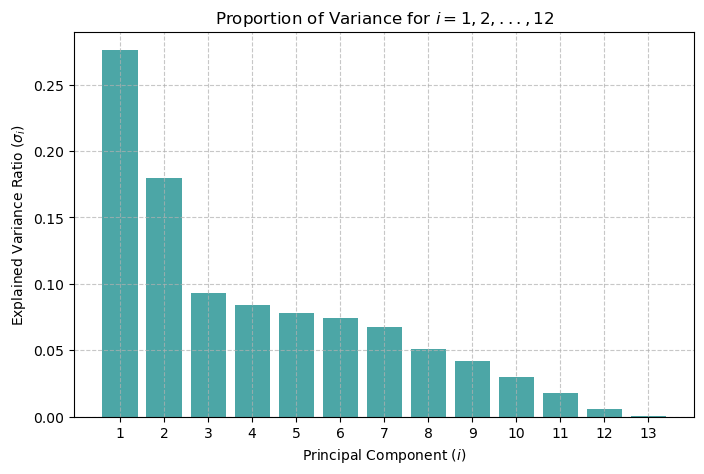

In [176]:
################# proportion of variance
#### vrf: var_ratio array

plt.figure(figsize=(8, 5))
plt.bar(components, vrf, color='teal', alpha=0.7)
plt.title('Proportion of Variance for $i=1,2,...,12$')
plt.xlabel('Principal Component ($i$)')
plt.ylabel('Explained Variance Ratio ($\\sigma_i$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)

# export
plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'var_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

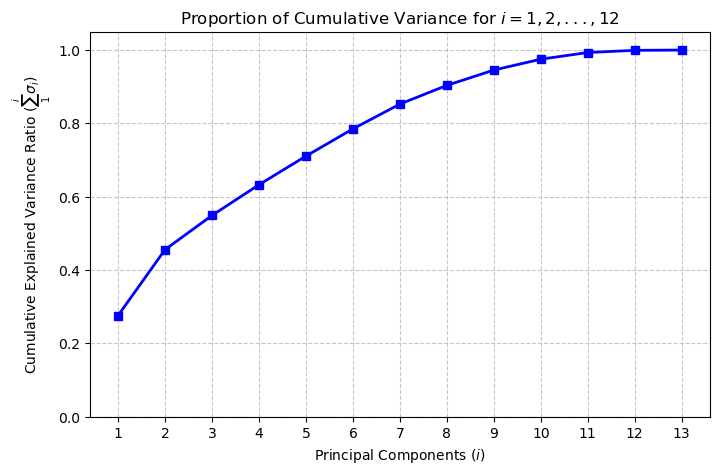

In [177]:
####################### cumulative variance plot
#### vrf: var_ratio array

cvrf = np.cumsum(vrf)
plt.figure(figsize=(8, 5))
plt.plot(components, cvrf, marker='s', color='b', linewidth=2)
plt.title('Proportion of Cumulative Variance for $i=1,2,...,12$')
plt.xlabel('Principal Components ($i$)')
plt.ylabel('Cumulative Explained Variance Ratio ($\\sum_1^i {\\sigma_i}$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim([0,1.05])

# export
plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'cvar_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

## Directions of the PCs


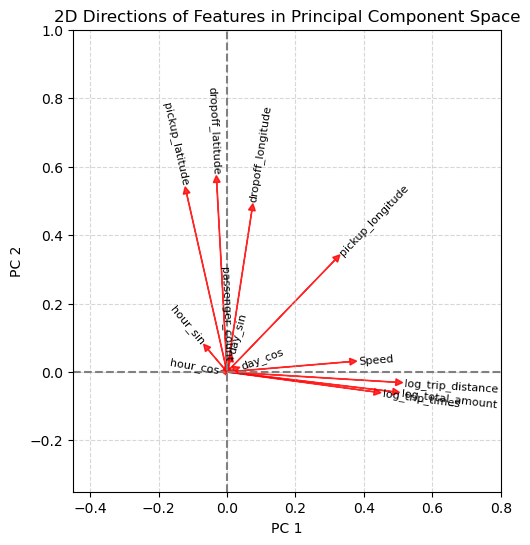

In [178]:
############################ plotting the directions of the principal components: 2 PC
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array

v_names = features_df.columns

PC1 = evecf[0]
PC2 = evecf[1]

plt.figure(figsize=(8,6))
offset = 0.005

for i in range(n_features):
    plt.arrow(0, 0, PC1[i], PC2[i],
              color='red', alpha=0.8, head_width=0.02, head_length=0.02,
              length_includes_head=True)
    ## some trigonometry
    rad = np.arctan2(PC2[i], PC1[i])
    deg = np.degrees(rad)

    offset_x = offset * np.cos(rad)
    offset_y = offset * np.sin(rad)

    if(PC1[i]<0):
      plt.text(PC1[i]+offset_x, PC2[i]+ offset_y, v_names[i],
             color='black', ha='right', va='center', rotation=deg+180, rotation_mode='anchor', fontsize=8)
    else:
      plt.text(PC1[i]+offset_x, PC2[i]+ offset_y, v_names[i],
             color='black', ha='left', va='center', rotation=deg, rotation_mode='anchor', fontsize=8)

# Set up the graph formatting
plt.gca().set_aspect('equal') # important for correct angled labels

plt.xlim(-0.45, 0.8)
plt.ylim(-0.35, 1.0)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.xlabel(f'PC 1')
plt.ylabel(f'PC 2')
plt.title('2D Directions of Features in Principal Component Space')
plt.grid(True, linestyle='--', alpha=0.5)

# Export the plot
plt.savefig(os.path.join(PROJECT_RESULT_PATH,'directions_plot_2d.png'), dpi=300, bbox_inches='tight')
plt.show()

## Transformed data onto to the new coordinate system*

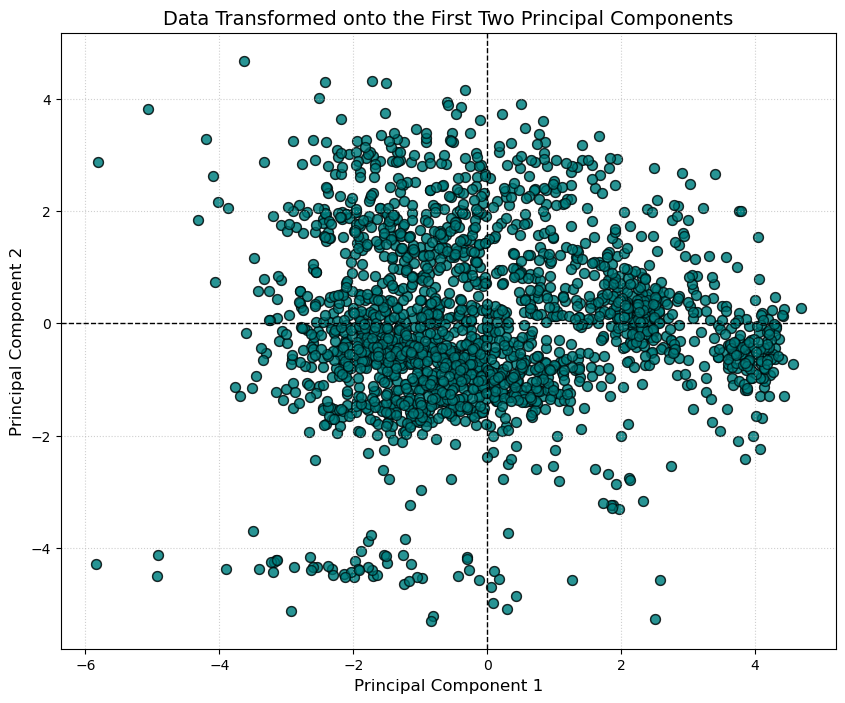

In [179]:
######################### PROJECTION: 2D
# tfdf : transformed data final
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array
SKIP_2D_PLOT = False

if not SKIP_2D_PLOT:
  plt.figure(figsize=(10, 8))
  plt.scatter(tfdf[:, 0], tfdf[:, 1],
              alpha=0.6, c='teal', edgecolors='k', s=50)

  plt.title('Data Transformed onto the First Two Principal Components', fontsize=14)
  plt.xlabel(f'Principal Component 1', fontsize=12)
  plt.ylabel(f'Principal Component 2', fontsize=12)

  plt.axhline(0, color='black', linewidth=1, linestyle='--')
  plt.axvline(0, color='black', linewidth=1, linestyle='--')
  plt.grid(True, linestyle=':', alpha=0.6)

  # export
  plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'data_2d_transformed.png'), dpi=300, bbox_inches='tight')
  plt.show()

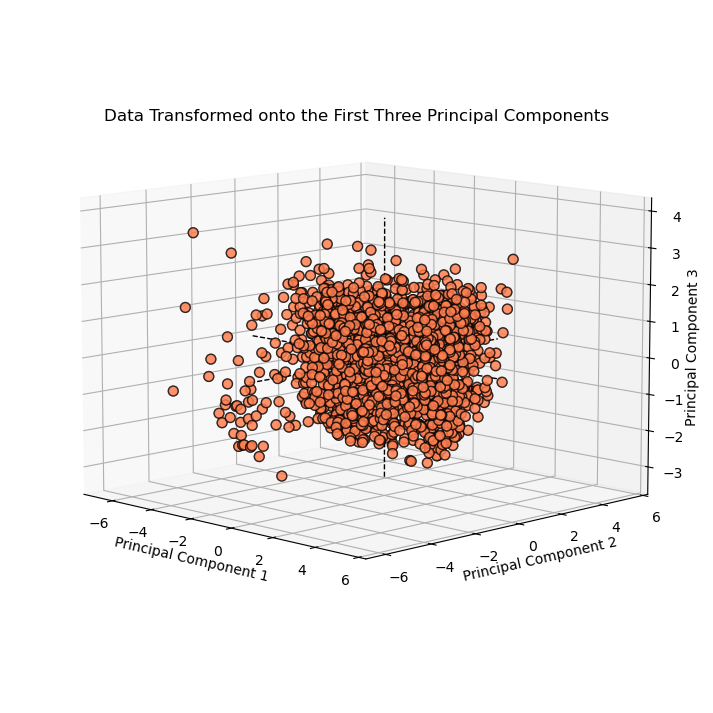

In [180]:
################### projection 3d
# tfdf : transformed data final
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array

SKIP_3D_PLOT = False

if not SKIP_3D_PLOT:
  fig = plt.figure(figsize=(12, 9))
  ax = fig.add_subplot(111, projection='3d')
  scatter = ax.scatter(tfdf[:, 0], tfdf[:, 1], tfdf[:, 2],
                      alpha=0.6, c='coral', edgecolors='k', s=50)

  ax.set_title('Data Transformed onto the First Three Principal Components', y = 0.9)

  ax.set_xlabel('Principal Component 1', labelpad=3)
  ax.set_ylabel('Principal Component 2', labelpad=3)
  ax.set_zlabel('Principal Component 3', labelpad=-1)

  xlim = ax.get_xlim()
  ylim = ax.get_ylim()
  zlim = ax.get_zlim()

  ax.plot(xlim, [0, 0], [0, 0], color='black', linestyle='--', linewidth=1)
  ax.plot([0, 0], ylim, [0, 0], color='black', linestyle='--', linewidth=1)
  ax.plot([0, 0], [0, 0], zlim, color='black', linestyle='--', linewidth=1)

  ### elev 10 20 30
  ### 45, 135, 225, or 315 azim
  ax.view_init(elev=10, azim=315)
  ax.set_box_aspect(None, zoom=0.90)
  # export
  plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'data_3d_transformed'), dpi=300, bbox_inches='tight')
  plt.show()

Let's visualize PCA based on Borough labels

In [181]:
labels = labels_df[LABEL_KEY]
colors = ground_truth = labels.astype("category").cat.codes
print(colors)
print(ground_truth.shape)

0       4
1       4
2       4
3       4
4       4
       ..
4153    0
4154    0
4155    0
4156    0
4157    0
Length: 4158, dtype: int8
(4158,)


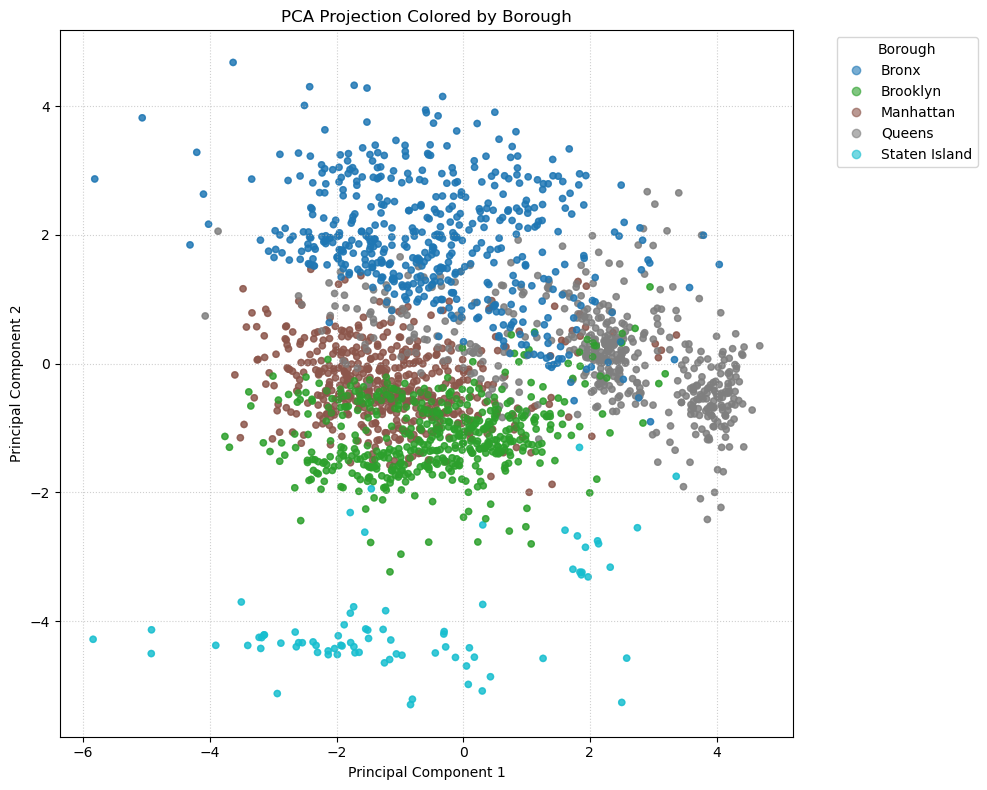

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

boroughs = labels_df["Borough"]

scatter = plt.scatter(
    tfdf[:, 0],
    tfdf[:, 1],
    c=colors,
    cmap="tab10",
    alpha=0.6,
    s=20
)

plt.title("PCA Projection Colored by Borough")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Create legend
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    boroughs.astype("category").cat.categories,
    title="Borough",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'pca_2d_colored.png'), dpi=300, bbox_inches='tight')
plt.show()

# Nonlinear Projections

## Multi-Dimensional Scaling

In [183]:
# Cosine similarity
#similarity = sklearn.metrics.pairwise.cosine_similarity(X=X, Y=None, dense_output=False) # Sparse matrix
#distances = 1 - similarity

# Euclidean Distances --> Seem to work better in our case
distances = sklearn.metrics.pairwise.euclidean_distances(X=X, Y=None)
print(f"[INFO] Computed similarity matrix of shape {distances.shape}")

[INFO] Computed similarity matrix of shape (4158, 4158)


In [184]:

# n_mds_trials: How many times to run random initialization config
# n_iters: number of sample points to check error

n_mds_trials = 10 # <------------- Setting this to 1 for fast results, but for higher trials the results were not significantly better

print(f"[INFO] There will be {n_mds_trials} trials for MDS random initializations.")

min_error = np.inf
best_config_mds = None
best_embedding_mds = None

# Try different random initial configurations
for i in range(n_mds_trials):

    random_state =  np.random.randint(low=1, high=100) # For reproducibility in the upcoming tasks
    print(f"[DEBUG] Chosen random state: {random_state}")

    #Based on: https://scikit-learn.org/stable/auto_examples/manifold/plot_mds.html
    mds = sklearn.manifold.MDS(
          n_components=2,
          max_iter=300,
          eps=1e-9,
          n_init=1,
          random_state=random_state,
          metric="precomputed",
          metric_mds=True, # If True, perform metric MDS; otherwise, perform nonmetric MDS.
          n_jobs=1,
          init="random", # init{‘random’, ‘classical_mds’} -> Note: if set to classical mds, n_inits is set to 1
          verbose=1
      )

    mds_start = time.time()
    fit = mds.fit(distances)
    X_mds, error = fit.embedding_, fit.stress_ # Stress value is mentioned in Week 4 Slides, p.19
    mds_end = time.time()
    print(f"[{i+1}/{n_mds_trials}] Performed MDS {X_mds.shape}, took {mds_end - mds_start:.4f} seconds. Final error: {error:.4f}")

    if error < min_error:
          min_error = error
          best_config_mds = mds
          best_embedding_mds = mds.embedding_
          print(f"\t[DEBUG] Updated minimum error to {min_error:.4f} (random state = {best_config_mds.random_state})")

[INFO] There will be 10 trials for MDS random initializations.
[DEBUG] Chosen random state: 57
[1/10] Performed MDS (4158, 2), took 84.7901 seconds. Final error: 16874467.2706
	[DEBUG] Updated minimum error to 16874467.2706 (random state = 57)
[DEBUG] Chosen random state: 57
[2/10] Performed MDS (4158, 2), took 83.1394 seconds. Final error: 16874467.2706
[DEBUG] Chosen random state: 23
[3/10] Performed MDS (4158, 2), took 83.6230 seconds. Final error: 15564979.0776
	[DEBUG] Updated minimum error to 15564979.0776 (random state = 23)
[DEBUG] Chosen random state: 76
[4/10] Performed MDS (4158, 2), took 83.4140 seconds. Final error: 16320569.0856
[DEBUG] Chosen random state: 13
[5/10] Performed MDS (4158, 2), took 83.1606 seconds. Final error: 15586212.4953
[DEBUG] Chosen random state: 70
[6/10] Performed MDS (4158, 2), took 83.3211 seconds. Final error: 15485271.0779
	[DEBUG] Updated minimum error to 15485271.0779 (random state = 70)
[DEBUG] Chosen random state: 73
[7/10] Performed MDS (4

In [185]:

# Choose the one that gives minimum error ------------------------------------------------------------------------------
# and we compute best configuration MDS for different iterations for the next task
# note that here we set max_iters to set iterations but convergence might be reached
# prior to max_iter.

n_iters = 10 # <------ Set higher than 1 for error-iter graph, to quickly debug we set this to 1

print("[INFO] Using the minimum error fit...")
print(f"[DEBUG] Best configuration MDS has random state = {best_config_mds.random_state} and params:\n {best_config_mds.get_params()}")

start_iters = 10
stop_iters = 300
max_iterations = np.linspace(start_iters, stop_iters, n_iters, dtype=int)

error_iterations = []
print(f"[DEBUG]: Run MDS for the max iterations: {max_iterations}")
for n, it in enumerate(max_iterations):

      best_config_mds.max_iter = it # Q: Does it re-compute or continue from the last iter? A: It recomputes
      best_config_mds.set_params()
      fit_iter = best_config_mds.fit(distances)
      error_iter = fit_iter.stress_
      print(f"[{n+1}/{len(max_iterations)}] Found error in this iteration: {error_iter:.2f} (max_iter = {best_config_mds.max_iter})")
      error_iterations.append(error_iter)



[INFO] Using the minimum error fit...
[DEBUG] Best configuration MDS has random state = 41 and params:
 {'dissimilarity': 'deprecated', 'eps': 1e-09, 'init': 'random', 'max_iter': 300, 'metric': 'precomputed', 'metric_mds': True, 'metric_params': None, 'n_components': 2, 'n_init': 1, 'n_jobs': 1, 'normalized_stress': 'auto', 'random_state': 41, 'verbose': 1}
[DEBUG]: Run MDS for the max iterations: [ 10  42  74 106 138 171 203 235 267 300]
[1/10] Found error in this iteration: 35464873.63 (max_iter = 10)
[2/10] Found error in this iteration: 29958464.72 (max_iter = 42)
[3/10] Found error in this iteration: 18060264.19 (max_iter = 74)
[4/10] Found error in this iteration: 16154006.53 (max_iter = 106)
[5/10] Found error in this iteration: 15678455.00 (max_iter = 138)
[6/10] Found error in this iteration: 15592865.98 (max_iter = 171)
[7/10] Found error in this iteration: 15483512.36 (max_iter = 203)
[8/10] Found error in this iteration: 15471507.73 (max_iter = 235)
[9/10] Found error in t

### Visualize MDS

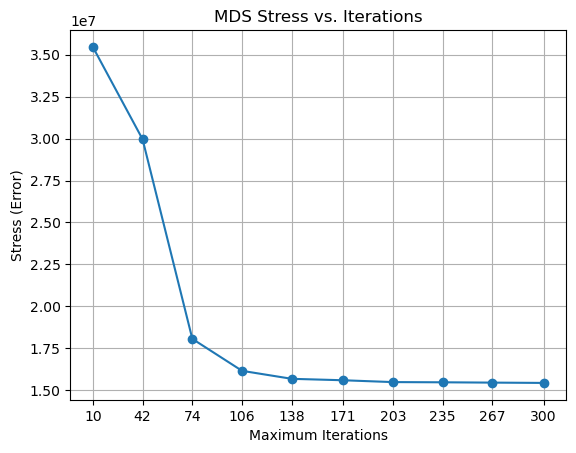

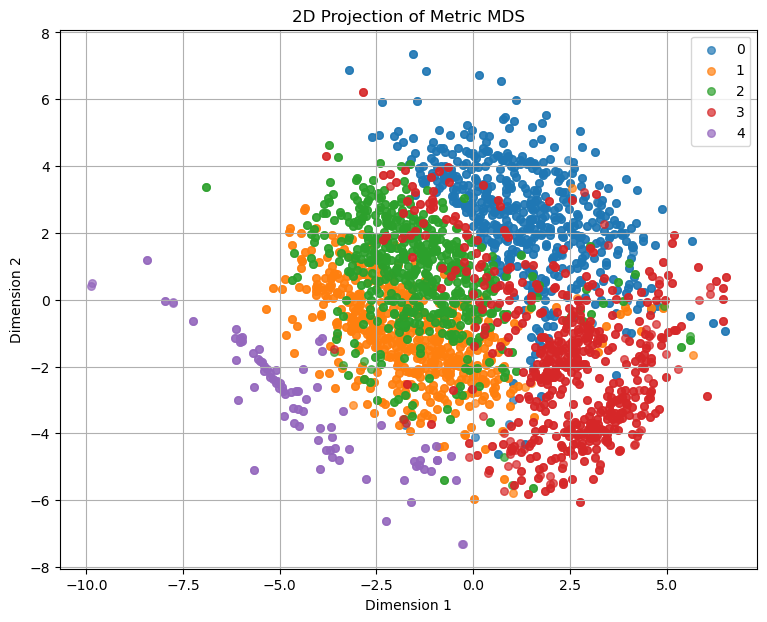

In [186]:
 # Plot the scree graph (error vs. iterations) for the chosen configuration
plot_mds_stress_vs_iterations(
        iterations=max_iterations,
        stress_values=error_iterations
)

# Plot the data by the chosen projection
visualize_2d_projection(
        projected_data=X_mds,
        labels= ground_truth, # This is to colorize the samples based on their GT class
        title="2D Projection of Metric MDS"
)


## Other Nonlinear Projections
* Locally Linear Embedding (LLE)
* IsoMap

In [187]:
# LLE ------------------------------------------------------------------------------------------------------------
embedding_lle = sklearn.manifold.LocallyLinearEmbedding(
                                                    n_components=2,
                                                    n_neighbors=30,
                                                    eigen_solver='dense', # 'arpack' might raise ValueError
                                                    )

In [188]:
# IsoMap --------------------------------------------------------------------------------------------------------
embedding_iso = sklearn.manifold.Isomap(
                                    n_components=2,
                                    n_neighbors=40, # NOTE: Increased neighbour count to silence the sparsity conversion warning
                                    )

In [189]:
embeddings = [(embedding_lle, "LLE"), (embedding_iso, "IsoMap")] # (embedding, "name")

[DEBUG] Performed LLE, took 2.1480 seconds.


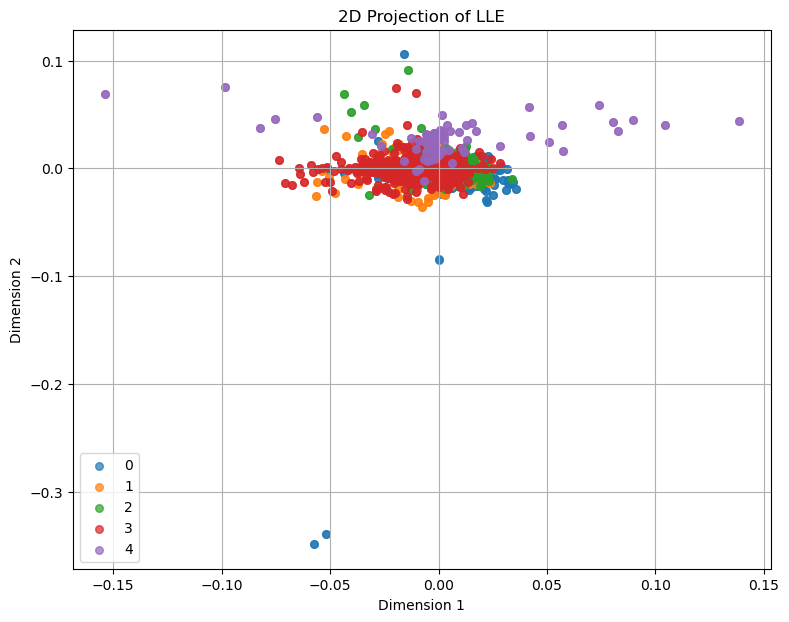

[DEBUG] Performed IsoMap, took 8.2350 seconds.


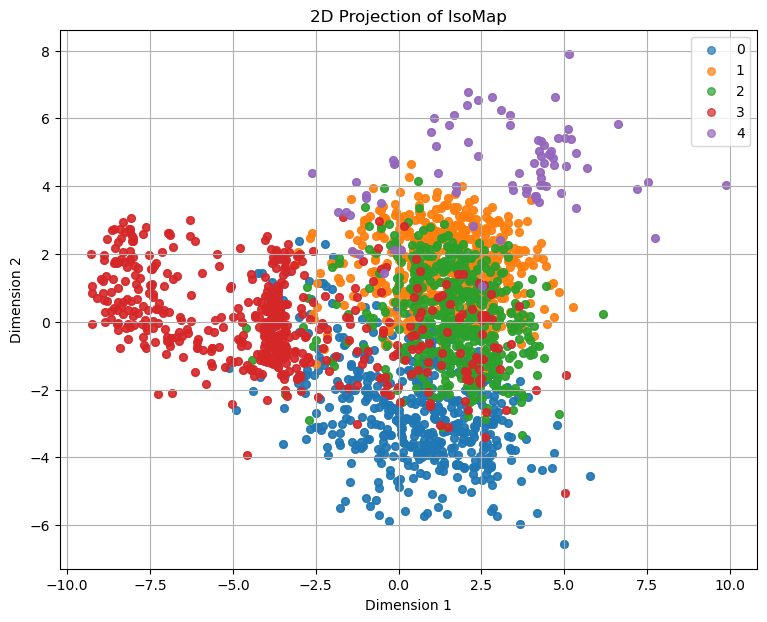

In [190]:
fitted_embeddings = []
for embedding, name in embeddings:
  task3_start = time.time()
  embed_fit = embedding.fit(X)
  task3_end = time.time()
  X_transformed = embed_fit.embedding_
  print(f"[DEBUG] Performed {name}, took {task3_end - task3_start:.4f} seconds.")

  fitted_embeddings.append((X_transformed, name))

  visualize_2d_projection(
          projected_data=X_transformed,
          labels= ground_truth, # This is to colorize the samples based on their GT class
          title=f"2D Projection of {name}"
    )

## Shepard Diagrams

[DEBUG] Original distances: min=0.0000, max=14.7559, std=1.3997
[DEBUG] Projected distances: min=0.0000, max=16.4348, std=2.2064


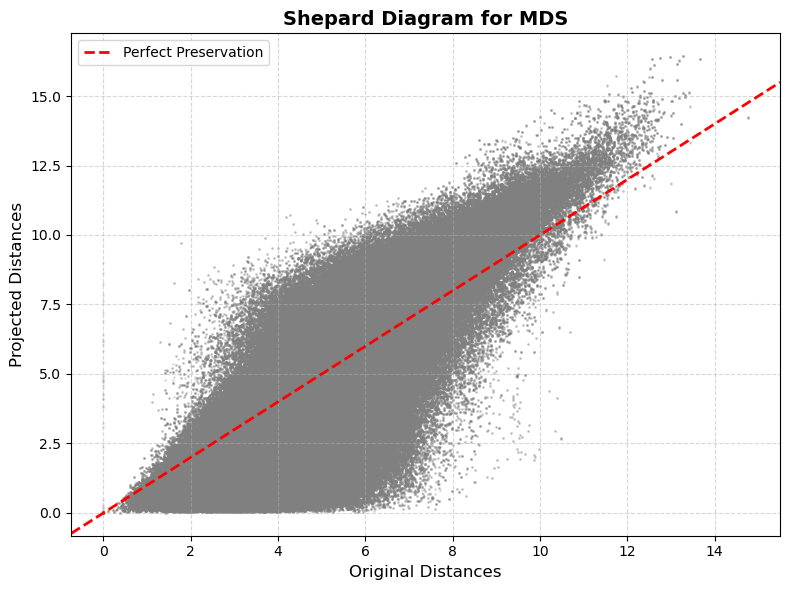

[DEBUG] Original distances: min=0.0000, max=14.7559, std=1.3997
[DEBUG] Projected distances: min=0.0000, max=0.4565, std=0.0224


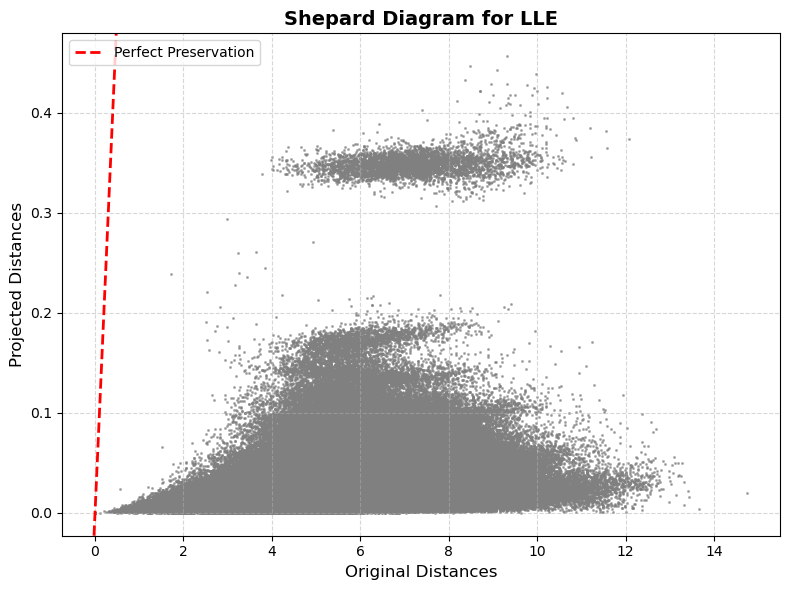

[DEBUG] Original distances: min=0.0000, max=14.7559, std=1.3997
[DEBUG] Projected distances: min=0.0000, max=19.5552, std=2.7146


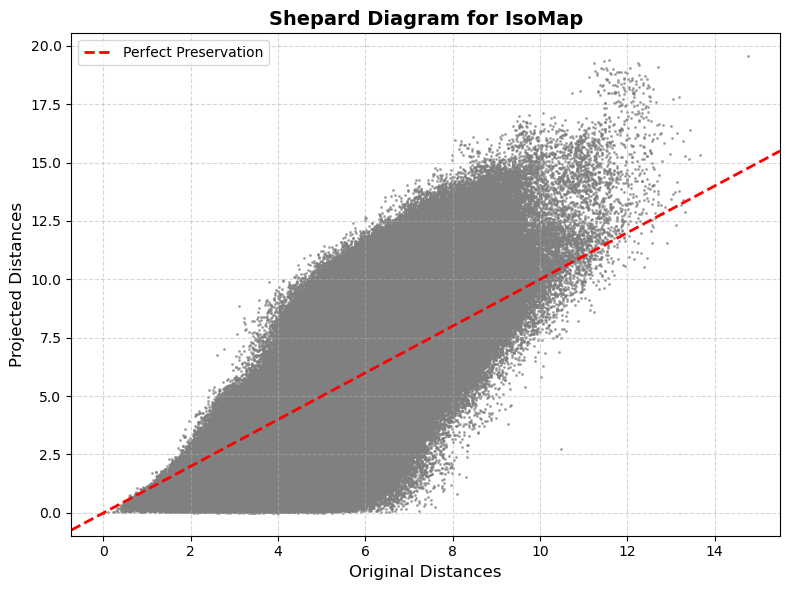

In [191]:
projections = [(best_embedding_mds, "MDS")]
for fit, name in fitted_embeddings:
  projections.append((fit, name)) # LLE, Isomap are appended


for projection, name in projections:
        if projection is not None:
            projected_distances = sklearn.metrics.pairwise.pairwise_distances(projection)
            plot_shepard_diagram_with_line(
                    original_distances=distances,
                    projected_distances=projected_distances,
                    title=f"Shepard Diagram for {name}"
            )


# Clustering

## K-Means

In [192]:

import pandas as pd
import numpy as np
import argparse
from sklearn.cluster import KMeans


In [193]:
# Some utilities

def print_cluster_sizes(labels):
    unique, counts = np.unique(labels, return_counts=True)
    print("Cluster sizes:")
    print("_______________________________")
    for u, c in zip(unique, counts):
        print(f"  Cluster {u}: {c} samples")
    print("_______________________________")


def plot_sse_vs_k(k_choices, sse_array):
    plt.figure(figsize=(7, 4))
    plt.plot(k_choices, sse_array, marker='o', linewidth=2)
    plt.title("K-Means: SSE vs. k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Sum of Squared Error (SSE)")
    plt.xticks(k_choices)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_RESULT_PATH, 'kmeans_sse_vs_k.png'), dpi=300, bbox_inches='tight')
    plt.show()


def save_clustering_to_parquet(index, labels, filepath):
    """Save cluster assignments alongside the original DataFrame index."""
    out = pd.DataFrame({"cluster": labels}, index=index)
    out.to_parquet(filepath)
    print(f"[INFO] Saved clustering to {filepath}")


def select_and_save_best_k(index, results, k_values=None):
    """
    Save clustering results for the chosen k values.
    Pass k_values explicitly (e.g. [9, 15]) or leave None to pick
    the two lowest-SSE keys automatically.
    """
    if k_values is None:
        sorted_k = sorted(results.keys(), key=lambda k: results[k]["sse"])
        k_values = sorted_k[:2]
        print(f"[INFO] Auto-selected best k values: {k_values}")

    for k in k_values:
        save_clustering_to_parquet(
            index=index,
            labels=results[k]["labels"],
            filepath=os.path.join(PROJECT_RESULT_PATH, f"kmeans_k{k}.parquet"),
        )




Main code for k-means


[INFO] Running k-means for k=4...
Cluster sizes:
_______________________________
  Cluster 0: 1218 samples
  Cluster 1: 980 samples
  Cluster 2: 1038 samples
  Cluster 3: 922 samples
_______________________________
[INFO] SSE for k=4: 35882.1163


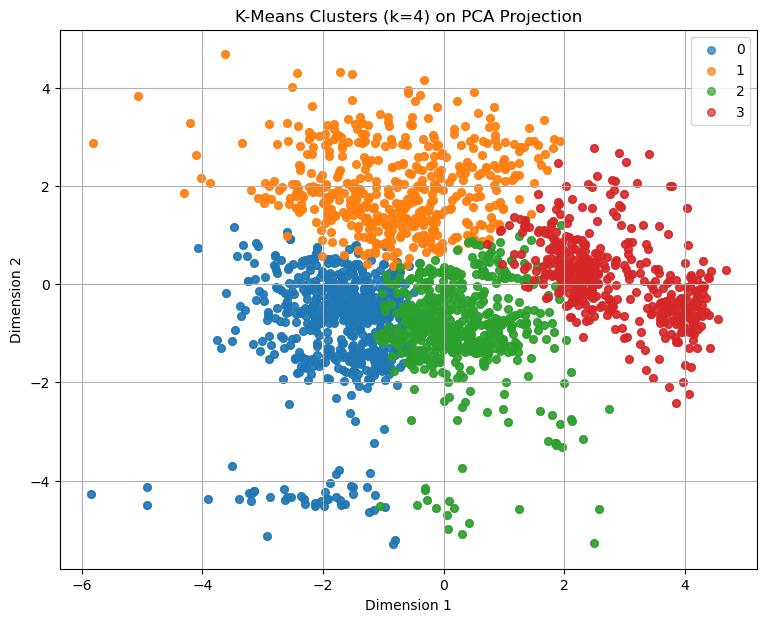

Figure saved to: .\result\proportional\k-4_latlong.png


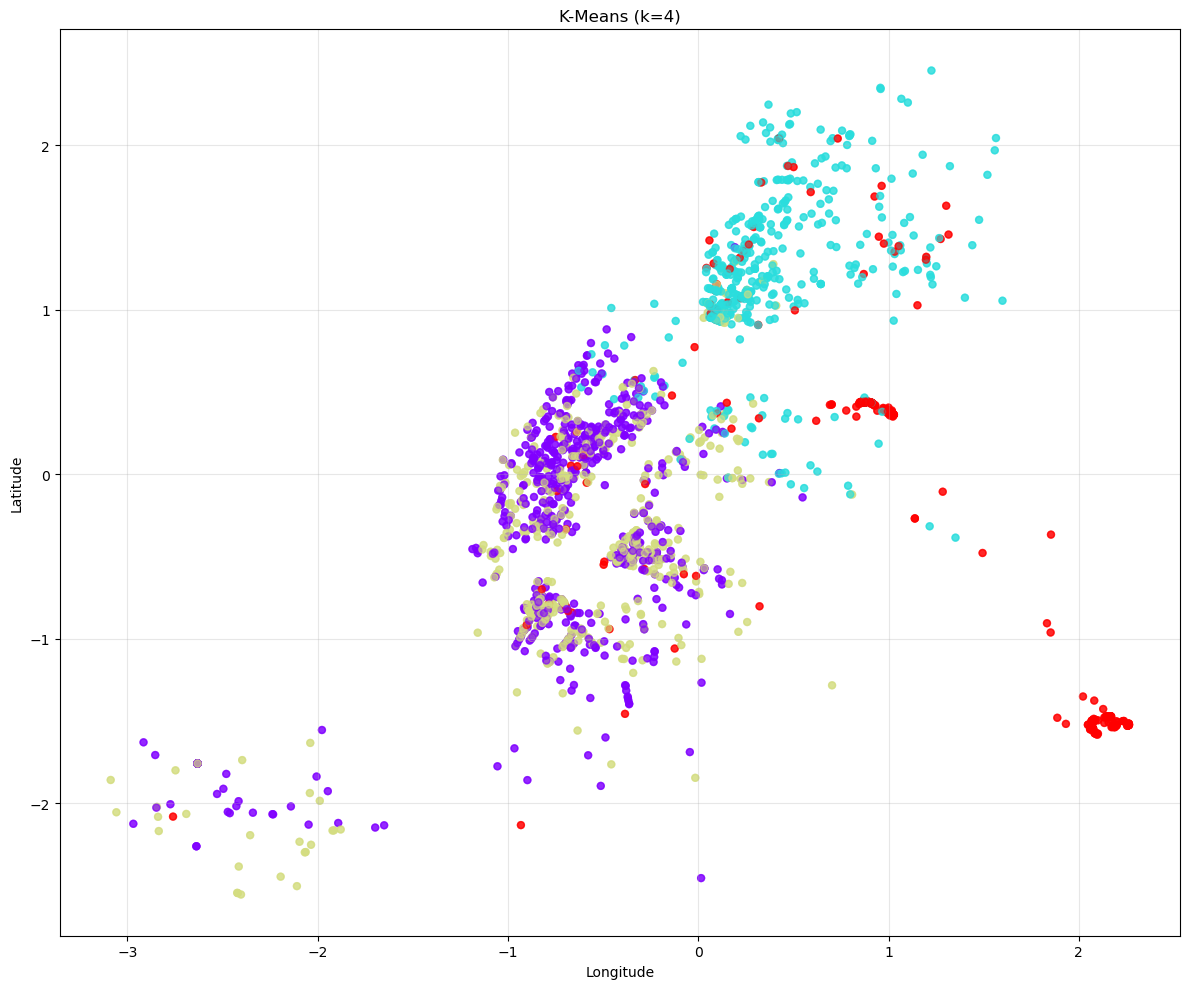


[INFO] Running k-means for k=5...
Cluster sizes:
_______________________________
  Cluster 0: 460 samples
  Cluster 1: 938 samples
  Cluster 2: 966 samples
  Cluster 3: 906 samples
  Cluster 4: 888 samples
_______________________________
[INFO] SSE for k=5: 34392.2237


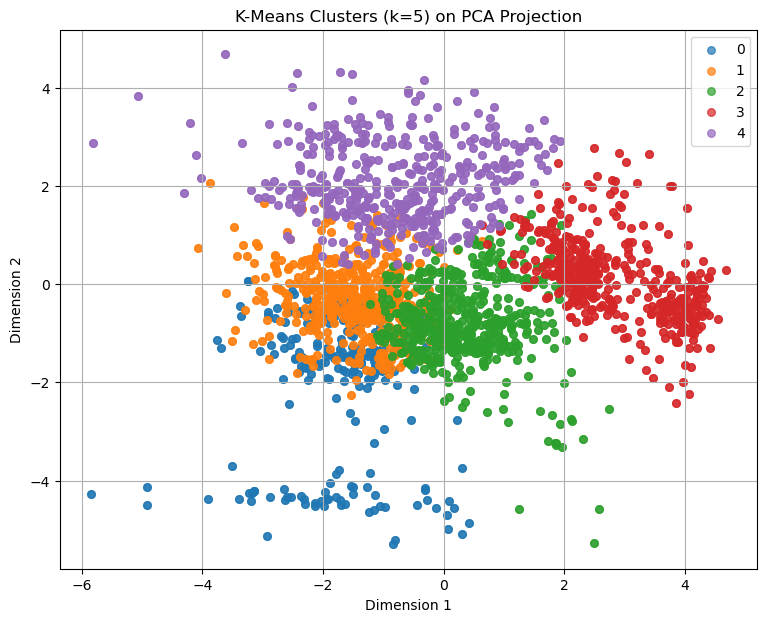

Figure saved to: .\result\proportional\k-5_latlong.png


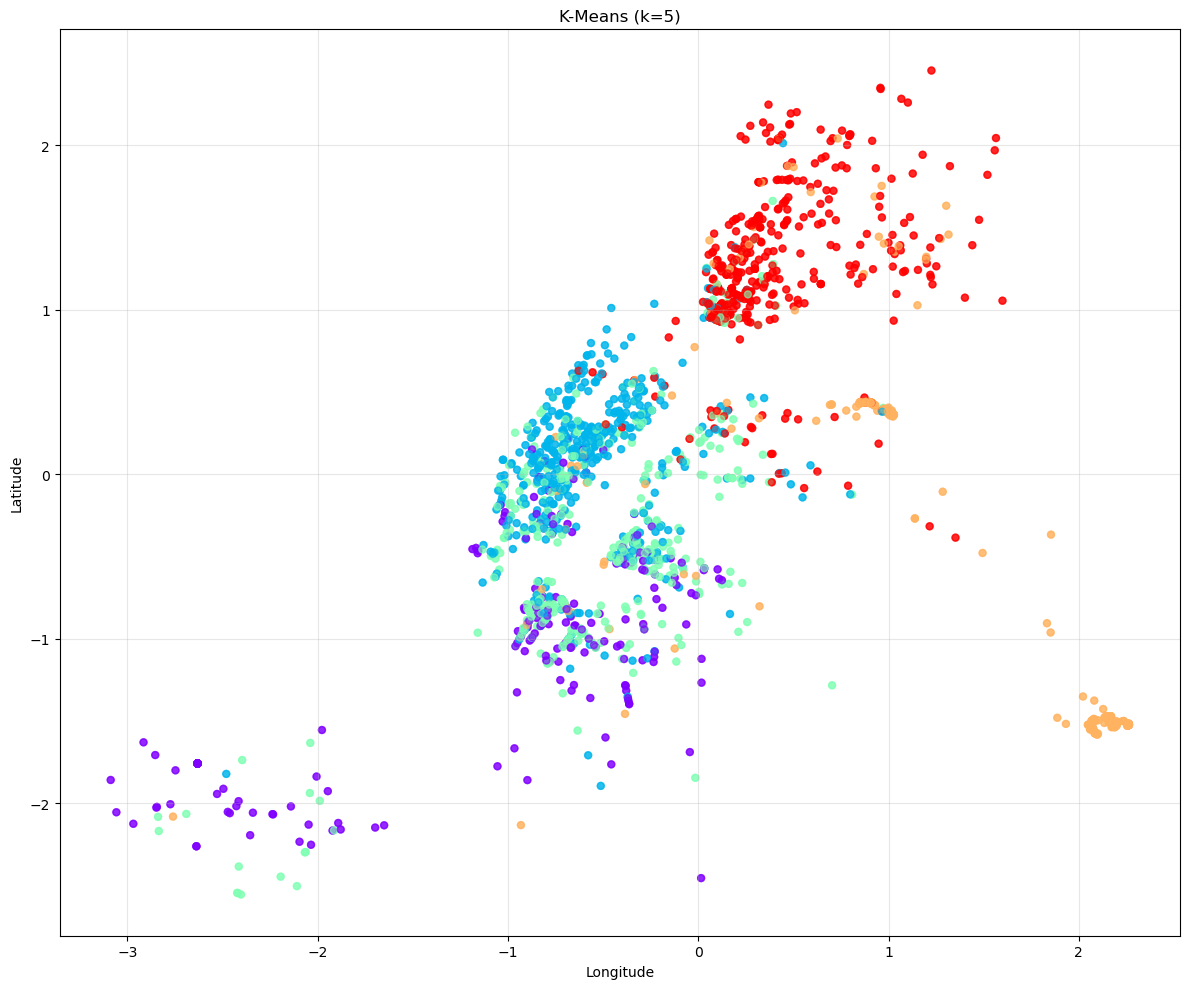


[INFO] Running k-means for k=15...
Cluster sizes:
_______________________________
  Cluster 0: 326 samples
  Cluster 1: 318 samples
  Cluster 2: 344 samples
  Cluster 3: 304 samples
  Cluster 4: 270 samples
  Cluster 5: 274 samples
  Cluster 6: 444 samples
  Cluster 7: 350 samples
  Cluster 8: 246 samples
  Cluster 9: 286 samples
  Cluster 10: 212 samples
  Cluster 11: 130 samples
  Cluster 12: 122 samples
  Cluster 13: 384 samples
  Cluster 14: 148 samples
_______________________________
[INFO] SSE for k=15: 24444.4682


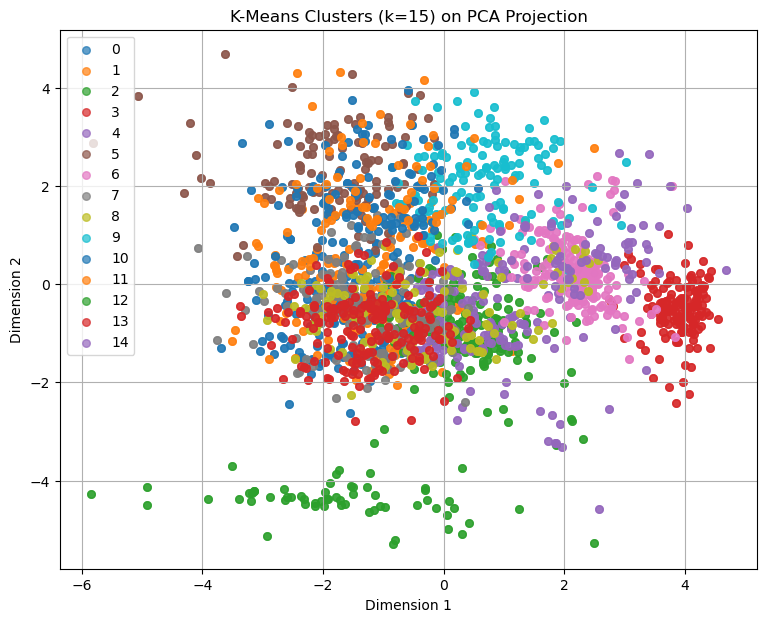

Figure saved to: .\result\proportional\k-15_latlong.png


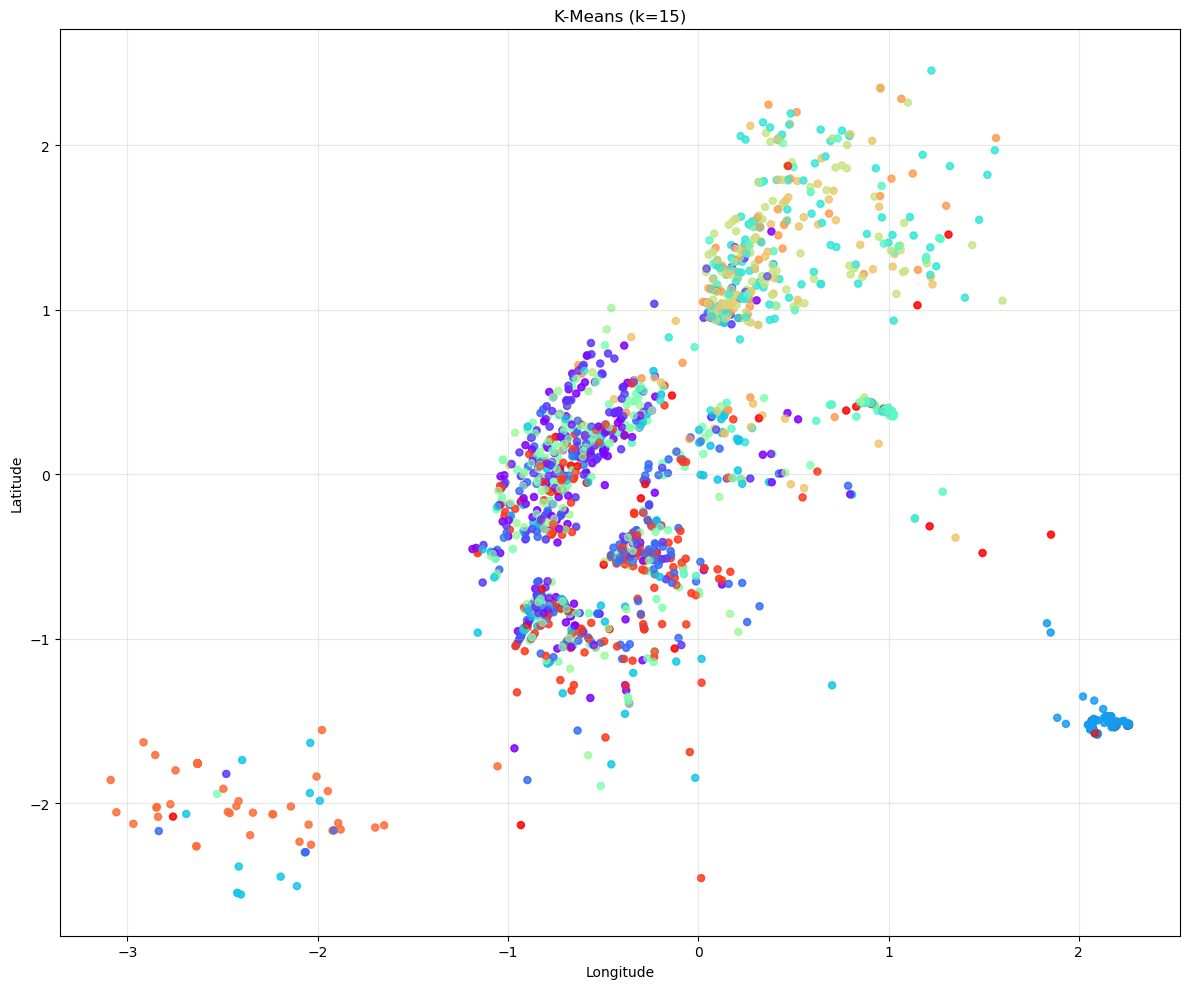

In [194]:

# features_df and labels_df are already defined above.
X = features_df.values  # numpy array for KMeans


# PCA projection re-used for 2-D visualisation (tfdf is already computed above)
projected_2d = tfdf[:, :2]  # first two PCs — swap for X_mds if preferred

K_CHOICES = [4, 5, 15]   # 5 for NYC boroughs, 263 for NYC taxi zones

sse_array = np.zeros(len(K_CHOICES))
results   = {}

for i, k in enumerate(K_CHOICES):
    print(f"\n[INFO] Running k-means for k={k}...")
    km = KMeans(n_clusters=k, random_state=42, n_init="auto", max_iter=3000).fit(X)
    print_cluster_sizes(km.labels_)

    # SSE: sum over all points of squared distance to their cluster centre
    mu  = km.cluster_centers_[km.labels_]   # shape (n_samples, n_features)
    sse = np.sum((X - mu) ** 2)
    sse_array[i] = sse
    print(f"[INFO] SSE for k={k}: {sse:.4f}")

    results[k] = {"labels": km.labels_, "sse": sse}

    # Visualise clusters on the 2-D PCA projection
    visualize_2d_projection(
        projected_data=projected_2d,
        labels=km.labels_,
        title=f"K-Means Clusters (k={k}) on PCA Projection",
    )

    plot_long_lat_based(features_df, colors=km.labels_, save_path=os.path.join(PROJECT_RESULT_PATH, f"k-{k}_latlong.png"), title=f"K-Means (k={k})")


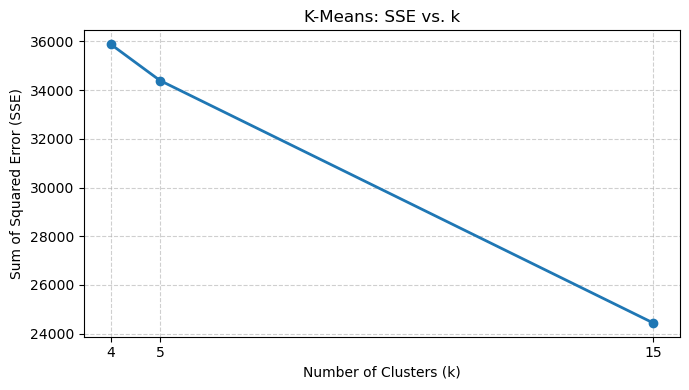

In [195]:

plot_sse_vs_k(k_choices=K_CHOICES, sse_array=sse_array)



In [196]:

# Pass k_values explicitly if you already know which ones are meaningful,
# or leave as None to auto-pick the two with lowest SSE.
select_and_save_best_k(
    index=features_df.index,
    results=results,
    k_values=[4,5,15],   # <--- Manually set e.g. [9, 15] or None
)



[INFO] Saved clustering to .\result\proportional\kmeans_k4.parquet
[INFO] Saved clustering to .\result\proportional\kmeans_k5.parquet
[INFO] Saved clustering to .\result\proportional\kmeans_k15.parquet


## Hierarchical Clustering

In [197]:
# ── 0. Helpers ────────────────────────────────────────────────────────────────

from scipy.cluster import hierarchy


def plot_dendrogram(X, link_type, labels):
    Z = hierarchy.linkage(X, link_type)

    fig = plt.figure(figsize=(20, 10))
    hierarchy.dendrogram(Z, labels=labels, leaf_rotation=30, leaf_font_size=8)

    plt.title(f"Dendrogram (Linkage: {link_type})", fontsize=14)
    plt.xlabel("Sample index")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_RESULT_PATH, f"dendrogram_{link_type}.png"),
        dpi=300, bbox_inches='tight'
    )
    plt.show()



In [198]:
# ── 1. Sample selection ───────────────────────────────────────────────────────

N_SELECTED = 20       # ← set to 0 to skip sampling and use the saved parquet below
SAVED_SAMPLE_PATH = os.path.join(PROJECT_RESULT_PATH, f"selected_{N_SELECTED}_samples.parquet")

if N_SELECTED > 0:
    rng = np.random.default_rng(seed=42)   # fix seed for reproducibility
    selected_idx = rng.choice(len(features_df), size=N_SELECTED, replace=False)
    selected_df  = features_df.iloc[selected_idx]

    # Save so the selection can be reused without re-running
    selected_df.to_parquet(SAVED_SAMPLE_PATH)
    print(f"[INFO] Saved {N_SELECTED} selected samples to {SAVED_SAMPLE_PATH}")

else:
    # Re-use a previously saved selection
    selected_df = pd.read_parquet(SAVED_SAMPLE_PATH)
    print(f"[INFO] Loaded existing sample from {SAVED_SAMPLE_PATH}")

print(f"[INFO] Working with sample of shape {selected_df.shape}")


[INFO] Saved 20 selected samples to .\result\proportional\selected_20_samples.parquet
[INFO] Working with sample of shape (20, 13)


In [199]:
# Use the ground truth
leaf_labels = ground_truth[selected_df.index].to_numpy()
X_selected  = selected_df.values


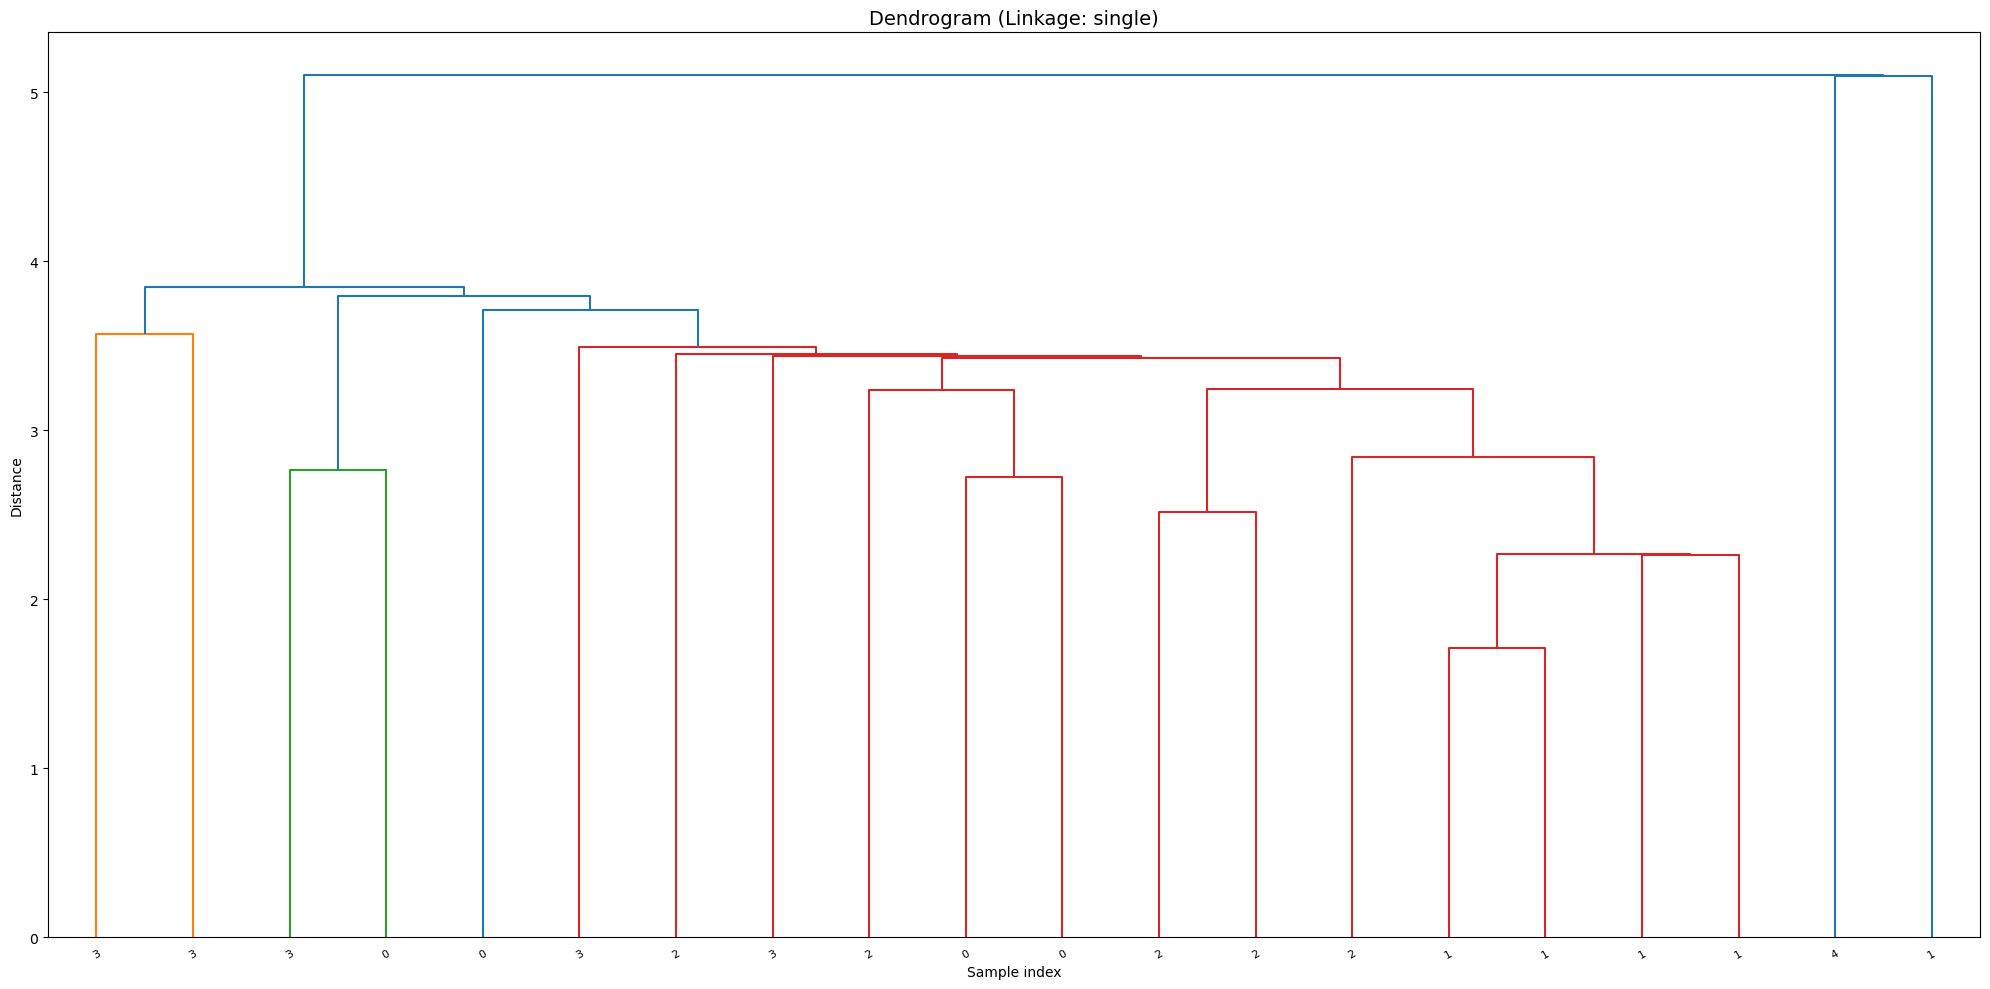

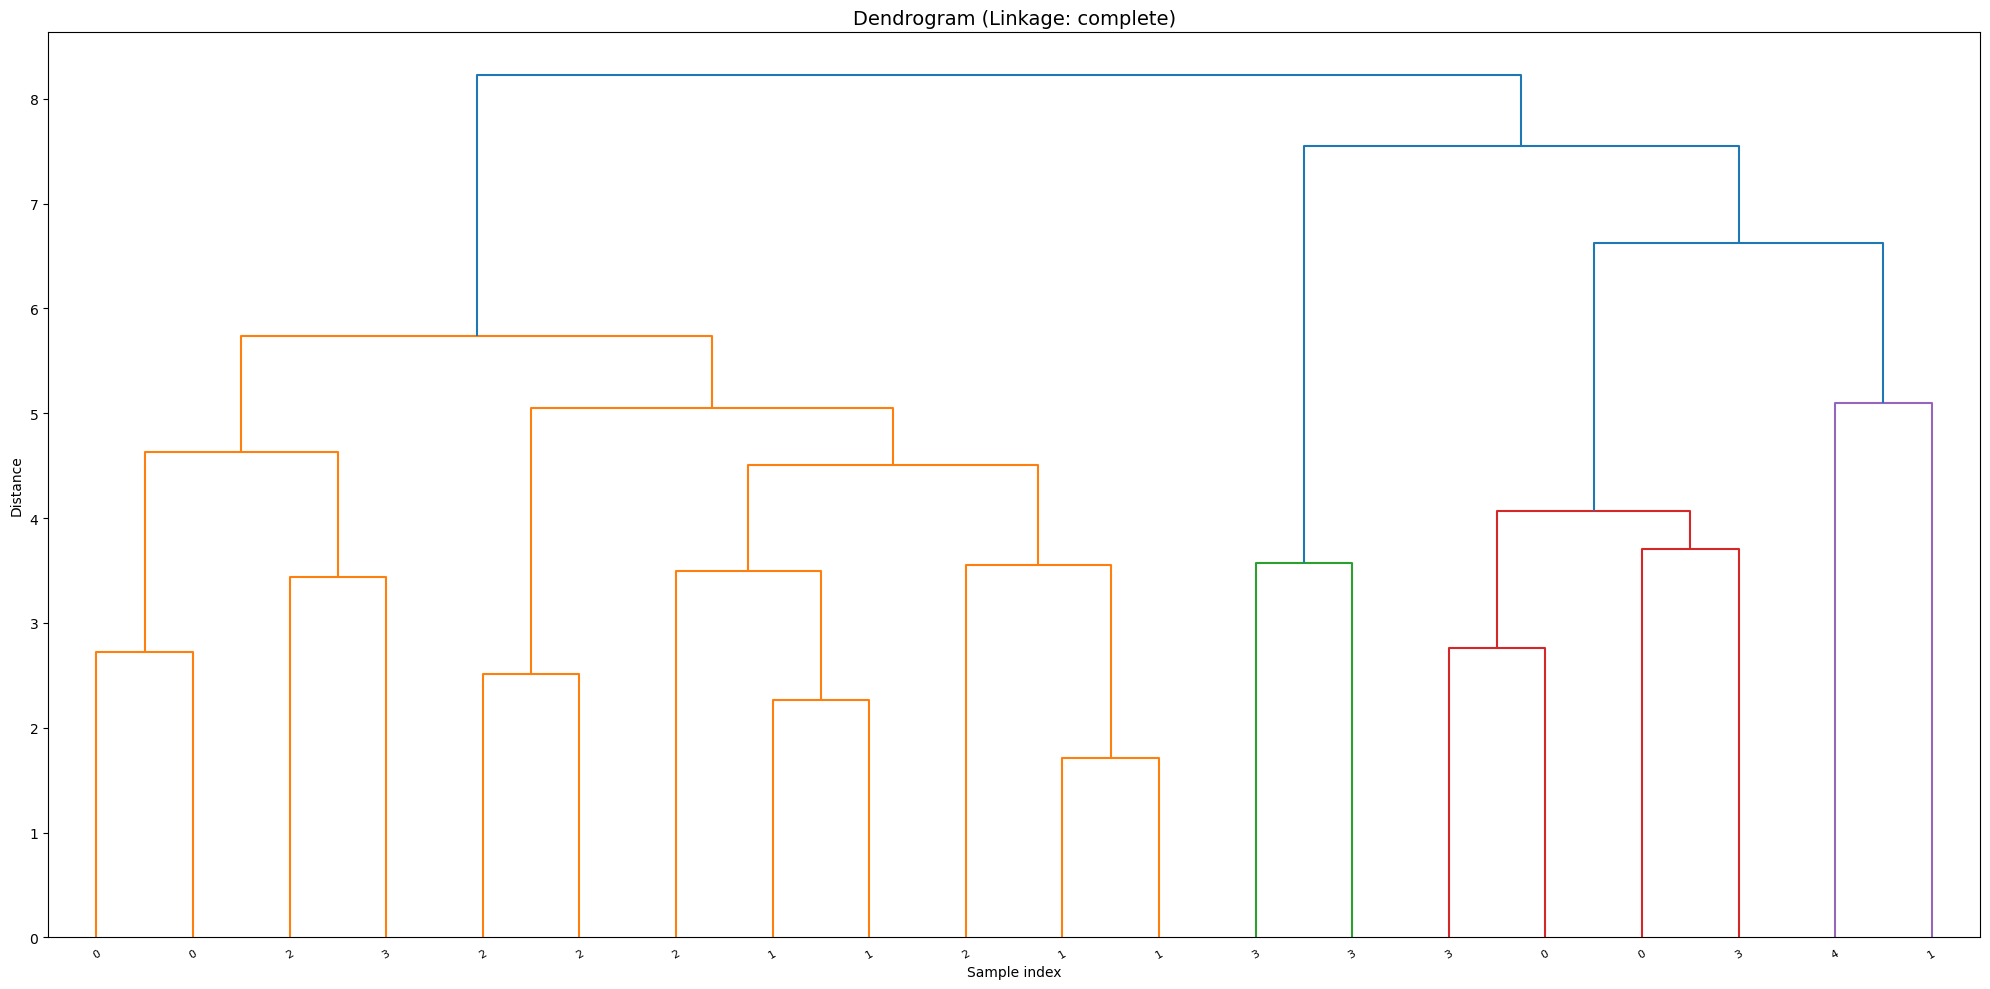

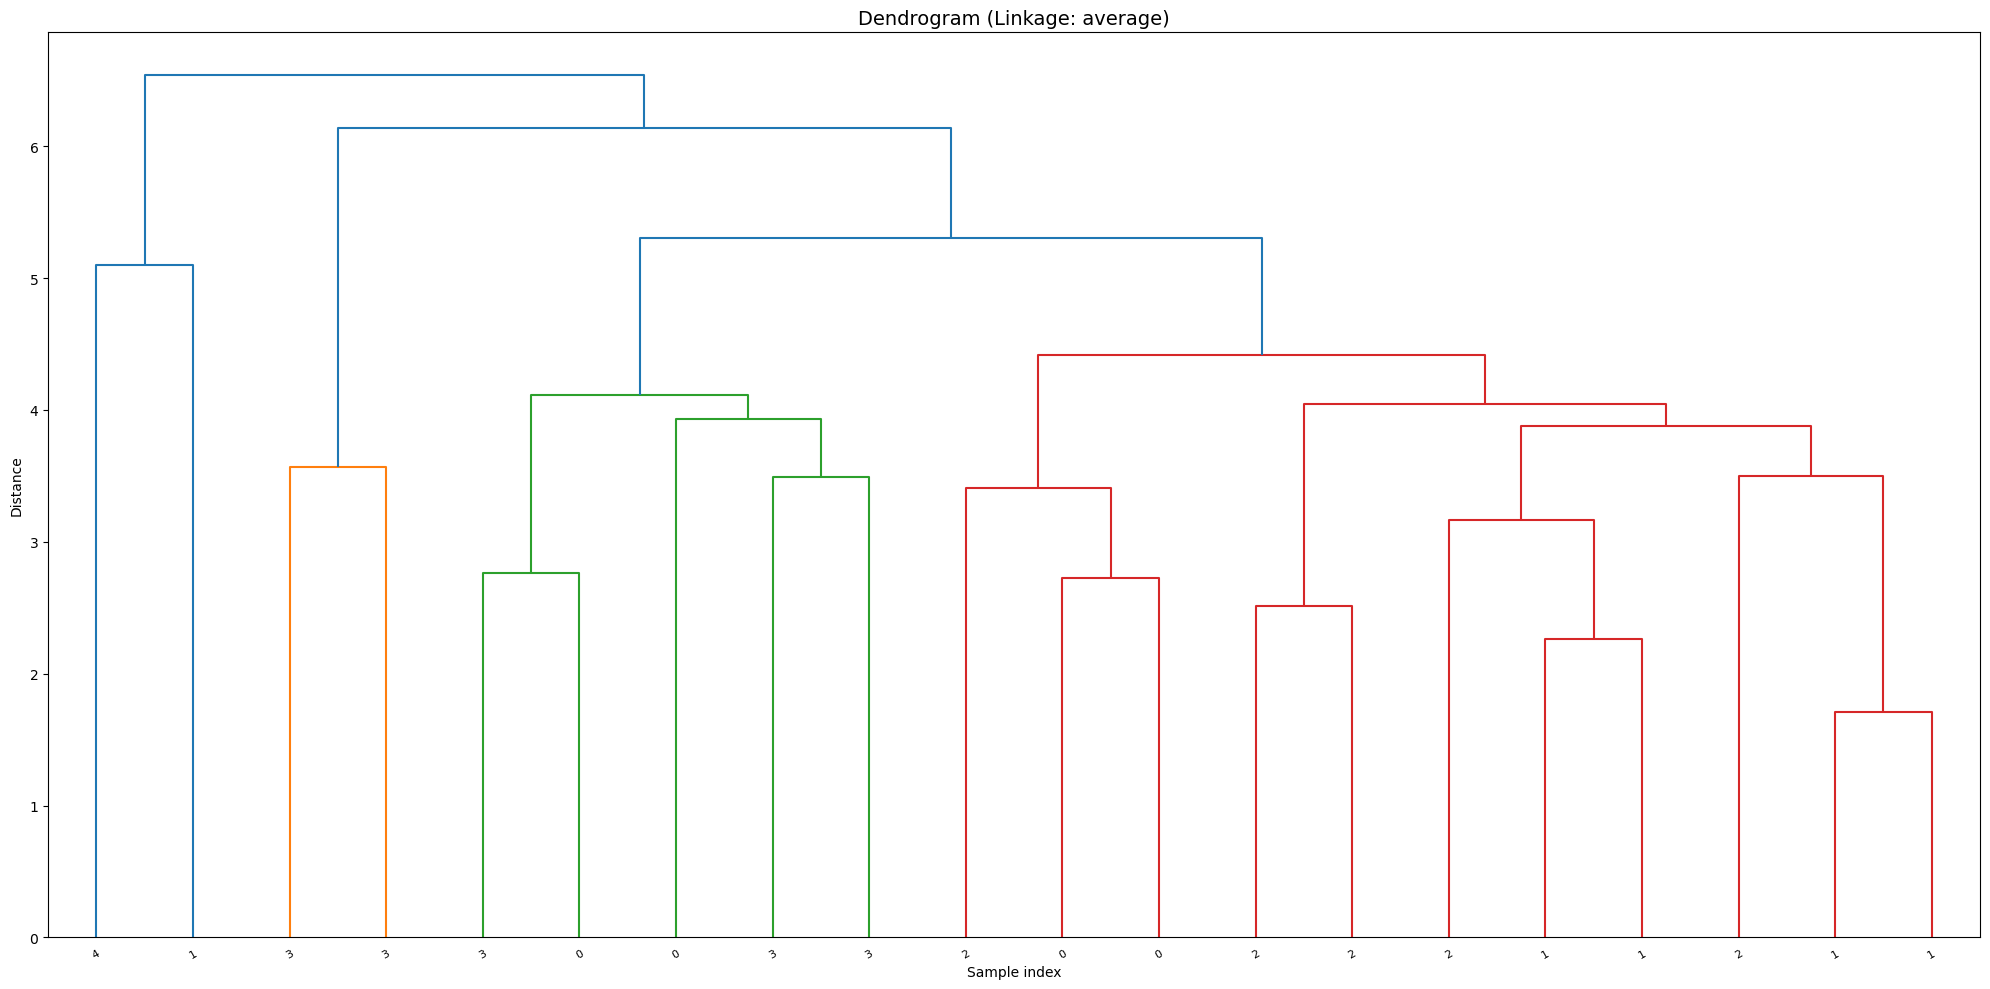

In [200]:

# ── 2. Plot dendrograms ───────────────────────────────────────────────────────

for link_type in ["single", "complete", "average"]:
    plot_dendrogram(X_selected, link_type=link_type, labels=leaf_labels)



# Evaluation and Validity

Assignment 5

In [201]:
!pip install permetrics

In [202]:

# ── 0. Dependencies ───────────────────────────────────────────────────────────

import sklearn.metrics as skm
from permetrics import ClusteringMetric



In [203]:
# ── 1. Helpers ────────────────────────────────────────────────────────────────

def compute_dunn_db_silhouette(X, labels):
    cm             = ClusteringMetric(X=X, y_pred=labels)
    dunn_index     = cm.dunn_index()
    db_index       = skm.davies_bouldin_score(X, labels)
    silhouette     = skm.silhouette_score(X=X, labels=labels)
    return dunn_index, db_index, silhouette


def print_metrics_table(metrics: dict):
    """
    metrics: {k_label_string: (dunn, db, silhouette)}
    e.g. {"k=9": (...), "k=15": (...)}
    """
    col_width = 16
    header = "Index" + "".join(k.rjust(col_width) for k in metrics)
    print(header)
    print("-" * len(header))

    index_names = ["Dunn", "Davies-Bouldin", "Silhouette"]
    for i, name in enumerate(index_names):
        row = name.ljust(20) + "".join(f"{v[i]:.4f}".rjust(col_width) for v in metrics.values())
        print(row)
    print()



In [204]:

# ── 2. Task 1 — Rand Index (k-means vs. ground truth) ────────────────────────

GROUND_TRUTH_COL = "Borough" # Options: PULocationID (k=263), DOLocationID (k=263), Borough (k=5)
ground_truth_codes = labels_df[GROUND_TRUTH_COL].astype("category").cat.codes.values

# Evaluate against the best k
BEST_K = 4

rand_index = skm.cluster.rand_score(
    labels_true=ground_truth_codes,
    labels_pred=results[BEST_K]["labels"]
)

print("=" * 50)
print(f"TASK 1 — Rand Index (k={BEST_K} vs. {GROUND_TRUTH_COL})")
print("=" * 50)
print(f"  Rand Index: {rand_index:.4f}\n")



TASK 1 — Rand Index (k=4 vs. Borough)
  Rand Index: 0.7812



In [205]:

# ── 3. Task 2 — Dunn / DB / Silhouette for two k-means results ───────────────

K_COMPARE = [4, 5, 15]   # WARN: must both exist in `results`

X_full = features_df.values

print("=" * 50)
print("TASK 2 — Internal Validity Indices")
print("=" * 50)

metrics = {}
for k in K_COMPARE:
    dunn, db, sil = compute_dunn_db_silhouette(X=X_full, labels=results[k]["labels"])
    metrics[f"k={k}"] = (dunn, db, sil)
    print(f"[INFO] Computed indices for k={k}")

print()
print_metrics_table(metrics)

# ----------------------------------------------------------------------------------
# NOTE:  Dunn Index implementation expects every cluster to have at least 2 points
# ----------------------------------------------------------------------------------


TASK 2 — Internal Validity Indices
[INFO] Computed indices for k=4
[INFO] Computed indices for k=5
[INFO] Computed indices for k=15

Index             k=4             k=5            k=15
-----------------------------------------------------
Dunn                          0.1982          0.2028          0.1585
Davies-Bouldin                2.1710          2.1420          1.8690
Silhouette                    0.1222          0.1147          0.1300



In [206]:

# ── Hierarchical clustering evaluation on the 20-sample subset ───

HIER_LINKAGE   = "single"   # Options: "single", "average"
HIER_K         = 5            # cut the dendrogram to this many clusters

print("=" * 50)
print(f"TASK 3 — Hierarchical Clustering Evaluation")
print(f"         Linkage: {HIER_LINKAGE}  |  k={HIER_K}")
print("=" * 50)

# Linkage matrix from the saved subset
Z_eval = sp.cluster.hierarchy.linkage(y=X_selected, method=HIER_LINKAGE)
hier_labels = sp.cluster.hierarchy.fcluster(Z_eval, t=HIER_K, criterion="maxclust")

# Ground truth for the subset rows (Borough codes)
subset_gt = labels_df.loc[
    pd.read_parquet(SAVED_SAMPLE_PATH).index, GROUND_TRUTH_COL
].astype("category").cat.codes.values

# Per-sample silhouette
sample_sil = skm.silhouette_samples(X_selected, hier_labels)
subset_boroughs = labels_df.loc[
    pd.read_parquet(SAVED_SAMPLE_PATH).index, GROUND_TRUTH_COL
].values

print(f"\n{'Cluster':<10}{'Borough':<20}{'Silhouette':>12}")
print("-" * 42)
for label, borough, s in zip(hier_labels, subset_boroughs, sample_sil):
    print(f"{label:<10}{borough:<20}{s:>12.4f}")

print(f"\n  Mean silhouette: {sample_sil.mean():.4f}")
print(f"  Rand Index (hierarchical vs. {GROUND_TRUTH_COL}): "
      f"{skm.cluster.rand_score(subset_gt, hier_labels):.4f}")
print()


TASK 3 — Hierarchical Clustering Evaluation
         Linkage: single  |  k=5

Cluster   Borough               Silhouette
------------------------------------------
3         Brooklyn                  0.1853
1         Queens                    0.3349
2         Queens                    0.4166
3         Bronx                     0.1925
3         Brooklyn                  0.1909
3         Brooklyn                  0.2858
3         Manhattan                 0.3052
3         Manhattan                 0.3064
1         Queens                    0.2789
4         Staten Island             0.0000
3         Bronx                     0.1673
3         Manhattan                 0.1570
2         Bronx                     0.4803
3         Brooklyn                  0.1958
3         Manhattan                 0.1028
3         Queens                   -0.0699
5         Brooklyn                  0.0000
3         Bronx                    -0.2813
3         Queens                   -0.1478
3         Manhattan